In [1]:
############## M2 and N2 in Idealized ROMS-Budgell Beaufort Jet ###############
# The purpose of this script is to plot time series of eddy energy (eddy
# kinetic energy- EKE; mean kinetic energy - MKE; total kinetic energy - TKE) 
# and M2 and N2 from output
# for the idealized ROMS-Budgell model based on the Beaufort shelf break jet.
# 
# Notes: 
# - This script runs in xroms
# - This script heavily uses code from Dylan Schlichting 
# - For M2 and N2, use the whole domain (and a little bit south of the 
#   northern boundary)
# - For energetics, slice toooooo the region the mixing is for? or keep the 
#   whole domain...? I think the whole lateral domain... which makes senseeeee
# - N2 (and maybe M2) have negative values so doing the log is a little messed
#   up for the PDF versions. However I think we want regions with unstable 
#   stratification (negative N2) sooo think on this...
#
#################################################################################

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as tick
import numpy as np
import xarray as xr
import xroms
import cartopy
from matplotlib.colors import BoundaryNorm
import cmocean.cm as cmo
import xarray as xr
from netCDF4 import Dataset
# from mpas_analysis.shared.io.utility import decode_strings
from glob import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
from matplotlib import ticker
from xhistogram.xarray import histogram
from matplotlib.ticker import FuncFormatter

import warnings 
warnings.filterwarnings("ignore") #turns off annoying warnings

In [3]:
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

## Load in the Output

In [4]:
# Set the paths for the grid and output
#grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'

# Constant forcing, U3C4, k-epsilon
grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
#his_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_his_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'
avg_file = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'
# Constant forcing, U3C4, gen
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# his_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_his_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc'
# avg_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc'
# Constant forcing, U3C4, kkl
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# his_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_his_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc'
# avg_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc'
# Constant forcing, U3C4, k-omega
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# his_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_his_ice_500m_w_dvd_constant_forcing_u3c4_komegaaltkmin_*.nc'
# avg_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komegaaltkmin_*.nc'
# Constant forcing, U3C4, kpp
# grd_file = '/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/Include/grd_1000_m.nc'
# his_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_his_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc'
# avg_file = '/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc'

In [5]:
# Load in the data
#ds, grid = xroms.open_mfnetcdf(glob(avg_file))
ds, grid = open_mfroms(glob(avg_file))

In [6]:
# # Remove the boundary cells otherwise periodic BC will 
# # cause the x_rho indexing to have overlapping values. This will NOT 
# # allow you plot or calculate gradients correctly. Just change h = None
# # to test this!
# h = 1 
# slices = dict(
#     xi_rho = slice(h, -h),
#     eta_rho = slice(h, -h),
#     xi_u   = slice(h, -h),
#     eta_v  = slice(h, -h),
# )

# ds = ds.isel(**slices)
# # === Rebuild ROMS dataset + grid (now halo-free) ===
# ds, grid = xroms.roms_dataset(ds,include_cell_volume=True)
# # Print this to confirm 
# # ds.x_rho.values
# # ds.x_u.values

## Process the Output - Energy

In [7]:
# Define a function to calculate the different 
# eddy energies (eddy kinetic (EKE), mean kinetic (MKE),
# and total kinetic (TKE) energy)

def energy_vint(ds,grid,etaslice,xislice,zslice):
    '''
Modifies volume-integrated eddy, mean, and total kinetic energy modified 
from Hetland (2017) and Schlichting et al 2024. For the beaufort jet, 
we will look only in the top 200 m 

Notes:
------
EKE = 1/2(uprime^2 + vprime^2). 
MKE = 1/2(ubar^2+vbar^2)
TKE = 1/2(u^2+v^2)
u = ubar+uprime, ubar = 1/L int_0^L u dx, aka alongshore mean
v = vbar+vprime
Velocities interpolated to rho points
    '''
    u = xroms.to_rho(ds.u, grid)
    urho = u.isel(eta_rho = etaslice, xi_rho = xislice).where(ds.z_rho>-zslice) 
    v = xroms.to_rho(ds.v, grid)
    vrho = v.isel(eta_rho = etaslice, xi_rho = xislice).where(ds.z_rho>-zslice)
    
    ubar = urho.mean('xi_rho')
    uprime = urho-ubar
    
    vbar = vrho.mean('xi_rho')
    vprime = vrho-vbar
    
    dV = ds.dV.isel(eta_rho = etaslice, xi_rho = xislice).where(ds.z_rho>-zslice) 
    #Mean kinetic energy
    mke = 0.5*(ubar**2+vbar**2)
    mke_int = (mke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])
    mke_initial = (mke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])[0] # Initial value for normalization
    mke_int.attrs = ''
    mke_int.name = 'mke'
    mke_initial.attrs = ''
    mke_initial.name = 'mke_initial'

    #Eddy kinetic energy
    eke = 0.5*(uprime**2 + vprime**2)
    eke_int = (eke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])
    eke_int.attrs = ''
    eke_int.name = 'eke'

    #Total kinetic energy 
    tke = 0.5*(urho**2+vrho**2)
    tke_int = (tke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])
    tke_int.attrs = ''
    tke_int.name = 'tke'     
    
    ds_energy = xr.merge([eke_int, mke_int, tke_int])
    return ds_energy

In [7]:
# Call the function to process the output
# Call the function, but take the whole lateral domain and top 150 m of water column.
# To do -- once new bulk fluxes is fixed, a few points away from the northern boundary should 
# be removed!

# Set the slicing
# If doing whole domain (except a little bit away from northern boundary)
xi_slice = slice(1,398) 
eta_slice = slice(0,990)

# If using same slicing as in mixing time series
#xi_slice = slice(1, 399)
#eta_slice =  slice(140, 420)

# Vertical
z_slice = 200 # meters

In [ ]:
# Call the function 
#dse = energy_vint(ds,grid,eta_slice,xi_slice,z_slice).compute()
#dse

### Save to a NetCDF  
Save the post-processed data to a netcdf so it can be read in for plotting.

In [ ]:
# Save the data to a netcdf

# Variables to save: tke, mke, eke

roms_tke_mke_eke = xr.Dataset(
    data_vars=dict(
        tke=(['ocean_time'], dse.tke.values),
        mke=(['ocean_time'], dse.mke.values),
        eke=(['ocean_time'], dse.eke.values),
    ),
    coords=dict(
        ocean_time=('ocean_time', ds.ocean_time.values)
    ),
    attrs=dict(description='Time-series of energetics of ROMS output including EKE, MKE, and TKE from 2-hourly model output; uses /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')
)

# Add attributes to the 'temperature' data variable
roms_tke_mke_eke['tke'].attrs['long_name'] = 'Total kinetic energy at 2-hourly intervals'
roms_tke_mke_eke['tke'].attrs['units'] = '(J/kg)'
roms_tke_mke_eke['mke'].attrs['long_name'] = 'Mean kinetic energy at 2-hourly intervals'
roms_tke_mke_eke['mke'].attrs['units'] = '(J/kg)'
roms_tke_mke_eke['eke'].attrs['long_name'] = 'Eddy kinetic energy at 2-hourly intervals'
roms_tke_mke_eke['eke'].attrs['units'] = '(J/kg)'

# Save to a netcdf
# Run with ice
#roms_tke_mke_eke.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_tke_mke_eke_2hr_ice_500m_const_forc_u3c4_keps_001.nc')
# Run without ice
#roms_phy_num_mix_salt_temp.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_tke_mke_eke_2hr_no_ice_500m_const_forc_u3c4_keps_001.nc')

### Plot the Output - Energetics

In [8]:
# Load in post-processed data
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
roms_energetics_u3c4_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_energetics_2hr_500m_const_forc_u3c4_keps_001.nc')

# Run without sea ice, 500 m resolution, u3c4, k-epsilon
roms_energetics_u3c4_keps_no_ice = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_energetics_2hr_500m_const_forc_no_ice_u3c4_keps_001.nc')

# Constant forcing, U3C4, gen
roms_energetics_u3c4_gen = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_energetics_2hr_500m_const_forc_u3c4_gen_001.nc')

# Constant forcing, U3C4, kkl
roms_energetics_u3c4_kkl = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_energetics_2hr_500m_const_forc_u3c4_kkl_001.nc')

# Constant forcing, U3C4, k-omega
roms_energetics_u3c4_komega = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_energetics_2hr_500m_const_forc_u3c4_komega_001.nc')

# Constant forcing, U3C4, kpp
roms_energetics_u3c4_kpp = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_energetics_2hr_500m_const_forc_u3c4_kpp_002.nc')

# Constant forcing, akima, k-epsilon
roms_energetics_akima_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_energetics_2hr_500m_const_forc_akima_keps_001.nc')

# Constant forcing, HSIMT, k-epsilon
roms_energetics_hsimt_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_energetics_2hr_500m_const_forc_hsimt_keps_001.nc')

# Constant forcing, MPDATA, k-epsilon
roms_energetics_mpdata_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_energetics_2hr_500m_const_forc_mpdata_keps_001.nc')

# Constant forcing, u3splitc4, k-epsilon
roms_energetics_u3splitc4_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_energetics_2hr_500m_const_forc_u3splitc4_keps_001.nc')


In [9]:
# Make time for the data - might not be needed with these data
# # Make a time for each output
# # Run with sea ice, 500 m resolution, u3c4, k-epsilon
# time_tmp = roms_energetics_u3c4_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # # Run without sea ice, 500 m resolution, u3c4, k-epsilon
# # time_tmp = roms_energetics_u3c4_keps_no_ice['ocean_time']
# # t0 = time_tmp.values[0]
# # time_u3c4_keps_no_ice = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # Constant forcing, U3C4, gen
# time_tmp = roms_energetics_u3c4_gen['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_gen = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # Constant forcing, U3C4, kkl
# time_tmp = roms_energetics_u3c4_kkl['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_kkl = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # Constant forcing, U3C4, k-omega
# time_tmp = roms_energetics_u3c4_komega['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_komega = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # Constant forcing, U3C4, kpp
# time_tmp = roms_energetics_u3c4_kpp['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_kpp = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # Constant forcing, akima, k-epsilon
# time_tmp = roms_energetics_akima_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_akima_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # Constant forcing, HSIMT, k-epsilon
# time_tmp = roms_energetics_hsimt_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_hsimt_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # Constant forcing, MPDATA, k-epsilon
# time_tmp = roms_energetics_mpdata_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_mpdata_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# # Constant forcing, u3splitc4, k-epsilon
# time_tmp = roms_energetics_u3splitc4_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_u3splitc4_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Make time array to use for plotting 
# # Time vector
# # I think do some stuff to get a vector of time for plotting?
# time = ds['ocean_time']
# t0 = time.values[0]

# time = np.array([
#     (t - t0).total_seconds() / 86400
#     for t in time.values
# ])

In [ ]:
# Plot time series comparing ice vs no ice for u3c4 keps
# (still need to process this data first)


In [10]:
roms_energetics_u3c4_gen.tke

<xarray.DataArray 'tke' (ocean_time: 1104)> Size: 9kB
[1104 values with dtype=float64]
Coordinates:
  * ocean_time  (ocean_time) float64 9kB 0.0 0.08333 0.1667 ... 91.83 91.92
Attributes:
    long_name:  Total kinetic energy at 2-hourly intervals
    units:      (J/kg)

In [11]:
# Make array of colors to use
energy_colors = ['blue', 'red', 'orange', 'green', 'deeppink', 'purple']
# Make colors to use
#energy_colors_all = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22', '#17becf', '#7f7f7f']
energy_colors_all = ["#fec64e", 'dimgrey', '#56b4e9', '#009e73', '#0072b2', '#d55e00', '#e377c2', '#4eab58', '#db6d00', '#d628c1']

Text(0.888, 0.314, 'c)')

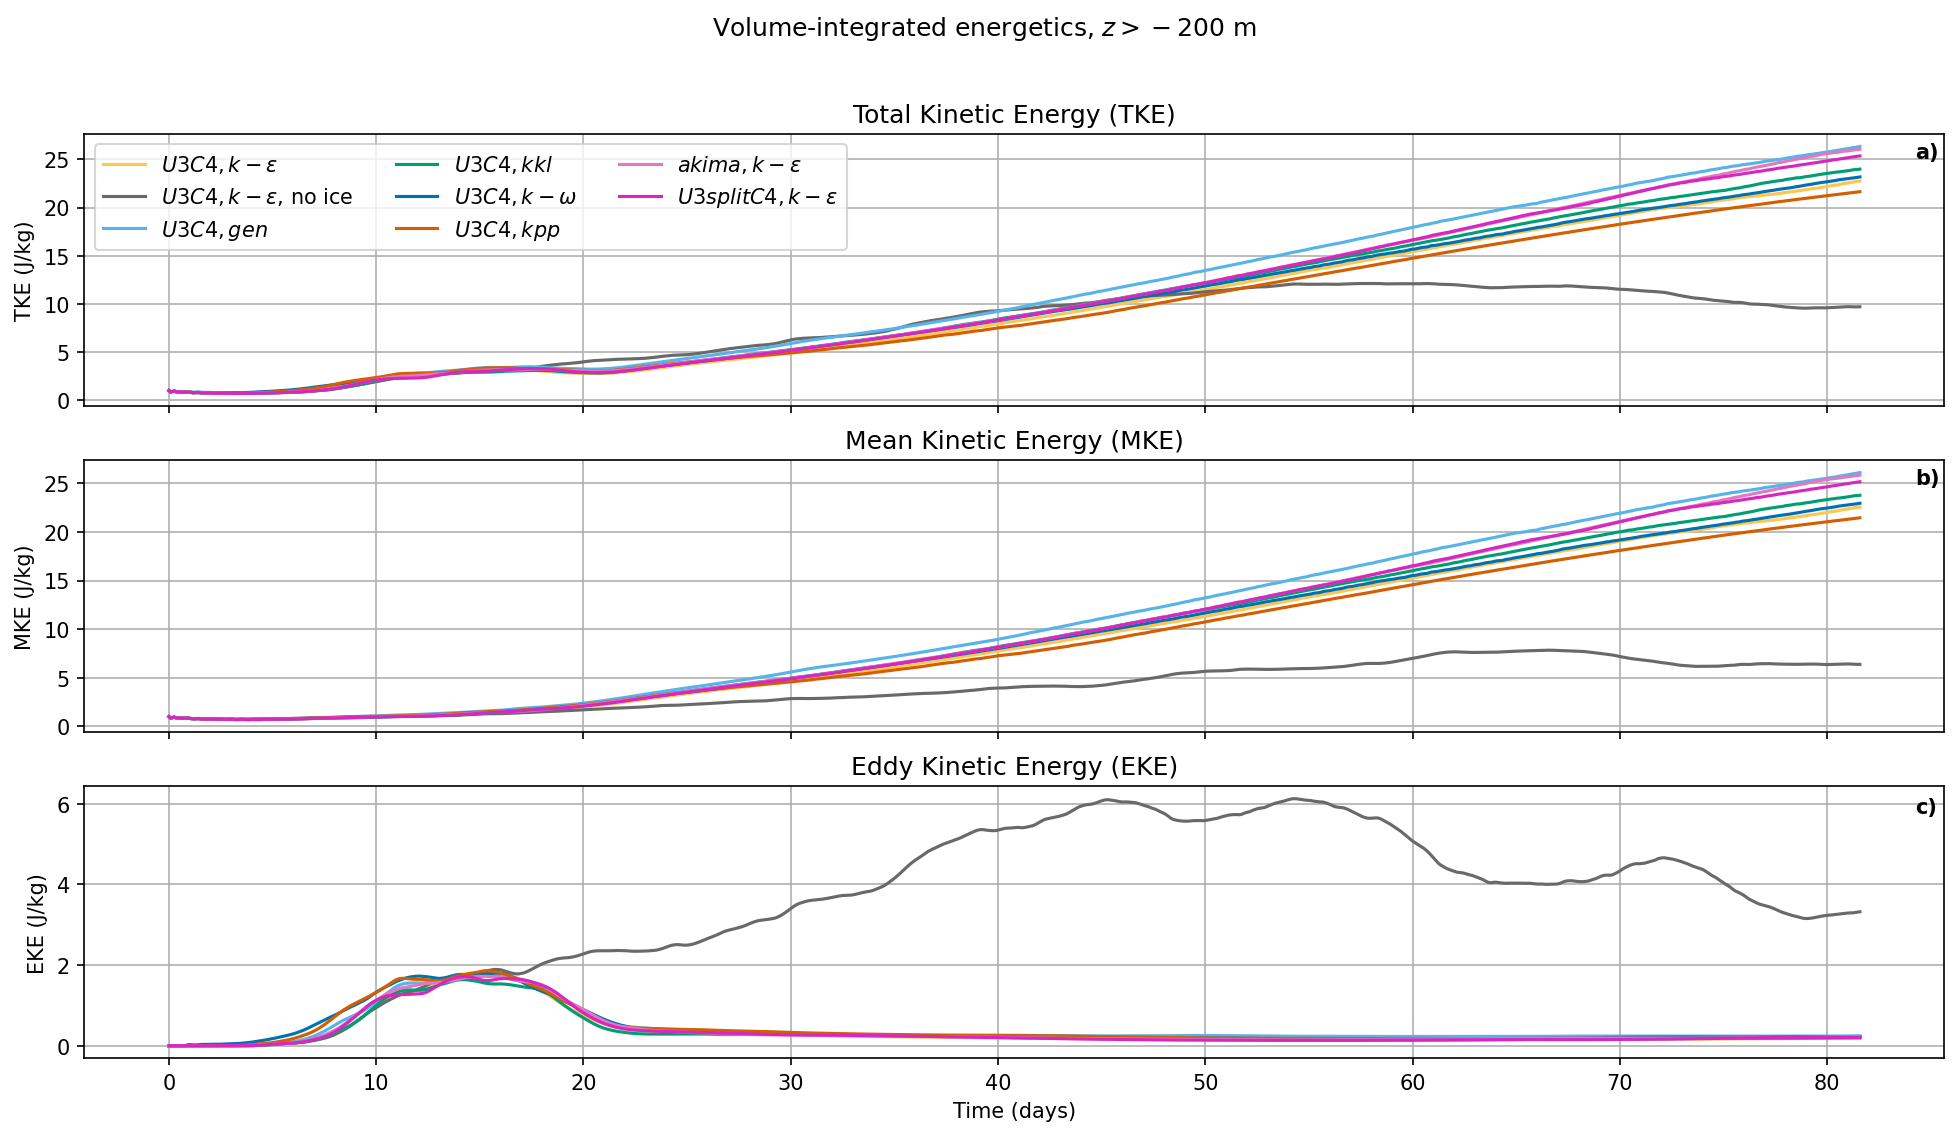

In [ ]:
# Plot time series comparing vertical mixing schemes

# Make the figure 
fig, ax = plt.subplots(3, 1, figsize=(16,8),dpi=150)

# Plot TKE
# --- Vertical Mixing Schemes ---
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[0].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.tke[:980] / roms_energetics_u3c4_keps.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[0])
# Run without sea ice, 500 m resolution, u3c4, k-epsilon
ax[0].plot(roms_energetics_u3c4_keps_no_ice.ocean_time[:980], (roms_energetics_u3c4_keps_no_ice.tke[:980] / roms_energetics_u3c4_keps_no_ice.mke[0]), label = '$U3C4,k-\epsilon$, no ice', color=energy_colors_all[1])
# Constant forcing, U3C4, gen
ax[0].plot(roms_energetics_u3c4_gen.ocean_time[:980], (roms_energetics_u3c4_gen.tke[:980] / roms_energetics_u3c4_gen.mke[0]), label = '$U3C4,gen$', color=energy_colors_all[2])
# Constant forcing, U3C4, kkl
ax[0].plot(roms_energetics_u3c4_kkl.ocean_time[:980], (roms_energetics_u3c4_kkl.tke[:980] / roms_energetics_u3c4_kkl.mke[0]), label = '$U3C4,kkl$', color=energy_colors_all[3])
# Constant forcing, U3C4, k-omega
ax[0].plot(roms_energetics_u3c4_komega.ocean_time[:980], (roms_energetics_u3c4_komega.tke[:980] / roms_energetics_u3c4_komega.mke[0]), label = '$U3C4,k-\omega$', color=energy_colors_all[4])
# Constant forcing, U3C4, kpp
ax[0].plot(roms_energetics_u3c4_kpp.ocean_time[:980], (roms_energetics_u3c4_kpp.tke[:980] / roms_energetics_u3c4_kpp.mke[0]), label = '$U3C4,kpp$', color=energy_colors_all[5])
# --- Horizontal Advection Schemes ---
# Constant forcing, akima, keps
ax[0].plot(roms_energetics_akima_keps.ocean_time[:980], (roms_energetics_akima_keps.tke[:980] / roms_energetics_akima_keps.mke[0]), label = '$akima,k-\epsilon$', color=energy_colors_all[6])
# Constant forcing, HSIMT, keps
#ax[0].plot(roms_energetics_hsimt_keps.ocean_time[:980], (roms_energetics_hsimt_keps.tke[:980] / roms_energetics_hsimt_keps.mke[0]), label = '$HSIMT,k-\epsilon$', color=energy_colors_all[7])
# Constant forcing, MPDATA, keps
#ax[0].plot(roms_energetics_mpdata_keps.ocean_time[:980], (roms_energetics_mpdata_keps.tke[:980] / roms_energetics_mpdata_keps.mke[0]), label = '$MPDATA,k-\epsilon$', color=energy_colors_all[8])
# Constant forcing, U3splitC4, keps
ax[0].plot(roms_energetics_u3splitc4_keps.ocean_time[:980], (roms_energetics_u3splitc4_keps.tke[:980] / roms_energetics_u3splitc4_keps.mke[0]), label = '$U3splitC4,k-\epsilon$', color=energy_colors_all[9])



# Plot MKE
# --- Vertical Mixing Schemes ---
# plt.plot(time, dse.mke / dse.mke[0], label = 'MKE', color='powderblue')
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[1].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.mke[:980] / roms_energetics_u3c4_keps.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[0])
# Run without sea ice, 500 m resolution, u3c4, k-epsilon
ax[1].plot(roms_energetics_u3c4_keps_no_ice.ocean_time[:980], (roms_energetics_u3c4_keps_no_ice.mke[:980] / roms_energetics_u3c4_keps_no_ice.mke[0]), label = '$U3C4,k-\epsilon$, no ice', color=energy_colors_all[1])
# Constant forcing, U3C4, gen
ax[1].plot(roms_energetics_u3c4_gen.ocean_time[:980], (roms_energetics_u3c4_gen.mke[:980] / roms_energetics_u3c4_gen.mke[0]), label = '$U3C4,gen$', color=energy_colors_all[2])
# Constant forcing, U3C4, kkl
ax[1].plot(roms_energetics_u3c4_kkl.ocean_time[:980], (roms_energetics_u3c4_kkl.mke[:980] / roms_energetics_u3c4_kkl.mke[0]), label = '$U3C4,kkl$', color=energy_colors_all[3])
# Constant forcing, U3C4, k-omega
ax[1].plot(roms_energetics_u3c4_komega.ocean_time[:980], (roms_energetics_u3c4_komega.mke[:980] / roms_energetics_u3c4_komega.mke[0]), label = '$U3C4,k-\omega$', color=energy_colors_all[4])
# Constant forcing, U3C4, kpp
ax[1].plot(roms_energetics_u3c4_kpp.ocean_time[:980], (roms_energetics_u3c4_kpp.mke[:980] / roms_energetics_u3c4_kpp.mke[0]), label = '$U3C4,kpp$', color=energy_colors_all[5])
# --- Horizontal Advection Schemes ---
# Constant forcing, akima, keps
ax[1].plot(roms_energetics_akima_keps.ocean_time[:980], (roms_energetics_akima_keps.mke[:980] / roms_energetics_akima_keps.mke[0]), label = '$akima,k-\epsilon$', color=energy_colors_all[6])
# Constant forcing, HSIMT, keps
#ax[1].plot(roms_energetics_hsimt_keps.ocean_time[:980], (roms_energetics_hsimt_keps.mke[:980] / roms_energetics_hsimt_keps.mke[0]), label = '$HSIMT,k-\epsilon$', color=energy_colors_all[7])
# Constant forcing, MPDATA, keps
#ax[1].plot(roms_energetics_mpdata_keps.ocean_time[:980], (roms_energetics_mpdata_keps.mke[:980] / roms_energetics_mpdata_keps.mke[0]), label = '$MPDATA,k-\epsilon$', color=energy_colors_all[8])
# Constant forcing, U3splitC4, keps
ax[1].plot(roms_energetics_u3splitc4_keps.ocean_time[:980], (roms_energetics_u3splitc4_keps.mke[:980] / roms_energetics_u3splitc4_keps.mke[0]), label = '$U3splitC4,k-\epsilon$', color=energy_colors_all[9])



# Plot EKE
# --- Vertical Mixing Schemes ---
# plt.plot(time, dse.eke / dse.eke[0], label = 'EKE', color='lightblue')
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[2].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.eke[:980] / roms_energetics_u3c4_keps.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[0])
# Run without sea ice, 500 m resolution, u3c4, k-epsilon
ax[2].plot(roms_energetics_u3c4_keps_no_ice.ocean_time[:980], (roms_energetics_u3c4_keps_no_ice.eke[:980] / roms_energetics_u3c4_keps_no_ice.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[1])
# Constant forcing, U3C4, gen
ax[2].plot(roms_energetics_u3c4_gen.ocean_time[:980], (roms_energetics_u3c4_gen.eke[:980] / roms_energetics_u3c4_gen.mke[0]), label = '$U3C4,gen$', color=energy_colors_all[2])
# Constant forcing, U3C4, kkl
ax[2].plot(roms_energetics_u3c4_kkl.ocean_time[:980], (roms_energetics_u3c4_kkl.eke[:980] / roms_energetics_u3c4_kkl.mke[0]), label = '$U3C4,kkl$', color=energy_colors_all[3])
# Constant forcing, U3C4, k-omega
ax[2].plot(roms_energetics_u3c4_komega.ocean_time[:980], (roms_energetics_u3c4_komega.eke[:980] / roms_energetics_u3c4_komega.mke[0]), label = '$U3C4,k-\omega$', color=energy_colors_all[4])
# Constant forcing, U3C4, kpp
ax[2].plot(roms_energetics_u3c4_kpp.ocean_time[:980], (roms_energetics_u3c4_kpp.eke[:980] / roms_energetics_u3c4_kpp.mke[0]), label = '$U3C4,kpp$', color=energy_colors_all[5])
# --- Horizontal Advection Schemes ---
# Constant forcing, akima, keps
ax[2].plot(roms_energetics_akima_keps.ocean_time[:980], (roms_energetics_akima_keps.eke[:980] / roms_energetics_akima_keps.mke[0]), label = '$akima,k-\epsilon$', color=energy_colors_all[6])
# Constant forcing, HSIMT, keps
#ax[2].plot(roms_energetics_hsimt_keps.ocean_time[:980], (roms_energetics_hsimt_keps.eke[:980] / roms_energetics_hsimt_keps.mke[0]), label = '$HSIMT,k-\epsilon$', color=energy_colors_all[7])
# Constant forcing, MPDATA, keps
#ax[2].plot(roms_energetics_mpdata_keps.ocean_time[:980], (roms_energetics_mpdata_keps.eke[:980] / roms_energetics_mpdata_keps.mke[0]), label = '$MPDATA,k-\epsilon$', color=energy_colors_all[8])
# Constant forcing, U3splitC4, keps
ax[2].plot(roms_energetics_u3splitc4_keps.ocean_time[:980], (roms_energetics_u3splitc4_keps.eke[:980] / roms_energetics_u3splitc4_keps.mke[0]), label = '$U3splitC4,k-\epsilon$', color=energy_colors_all[9])



# plt.plot(time, dse.tke / dse.tke[0], label = 'TKE', color='navyblue')
# plt.plot(time, dse.mke / dse.mke[0], label = 'MKE', color='powderblue')
# plt.plot(time, dse.eke / dse.mke[0], label = 'EKE', color='lightblue')


# Add legend
ax[0].legend(ncols=3)
#ax[1].legend(ncols=3)
#ax[2].legend(ncols=3)

# Label Plots
# # x-axes
ax[0].set_xticklabels([])
ax[1].set_xticklabels([])
ax[2].set_xlabel('Time (days)')

# Add grid
ax[0].grid()
ax[1].grid()
ax[2].grid()

# y-axes
ax[0].set_ylabel('TKE (J/kg)')
ax[1].set_ylabel('MKE (J/kg)')
ax[2].set_ylabel('EKE (J/kg)')

# titles
fig.suptitle('Volume-integrated energetics, $z>-200$ m')
ax[0].set_title('Total Kinetic Energy (TKE)')
ax[1].set_title('Mean Kinetic Energy (MKE)')
ax[2].set_title('Eddy Kinetic Energy (EKE)')

# Add subplot labels
fig.text(0.888, 0.860, 'a)', color='black', weight='bold')
fig.text(0.888, 0.588, 'b)', color='black', weight='bold')
fig.text(0.888, 0.314, 'c)', color='black', weight='bold')

In [32]:
# Set the time indices for different ice conditions
# Find where this is different values
#print('10%: ', np.where(avg_ice_conc >= 0.10))
idx_10_perc = 134
#print('15%: ', np.where(avg_ice_conc >= 0.15))
idx_15_perc = 143
#print('25%: ', np.where(avg_ice_conc >= 0.25))
idx_25_perc = 160
#print('35%: ', np.where(avg_ice_conc >= 0.35))
idx_35_perc = 169
#print('45%: ', np.where(avg_ice_conc >= 0.45))
idx_45_perc = 179
#print('50%: ', np.where(avg_ice_conc >= 0.50))
idx_50_perc = 184
#print('60%: ', np.where(avg_ice_conc >= 0.60))
idx_60_perc = 195
#print('70%: ', np.where(avg_ice_conc >= 0.70))
idx_70_perc = 209
#print('80%: ', np.where(avg_ice_conc >= 0.80))
idx_80_perc = 228
#print('90%: ', np.where(avg_ice_conc >= 0.90))
idx_90_perc = 260
#print('95%: ', np.where(avg_ice_conc >= 0.95))
idx_95_perc = 300
#print('98%: ', np.where(avg_ice_conc >= 0.98))
idx_98_perc = 375

# Set time index for ice entering the box
time_idx_15_perc_south_bnd = 95

Text(0.883, 0.23, 'f)')

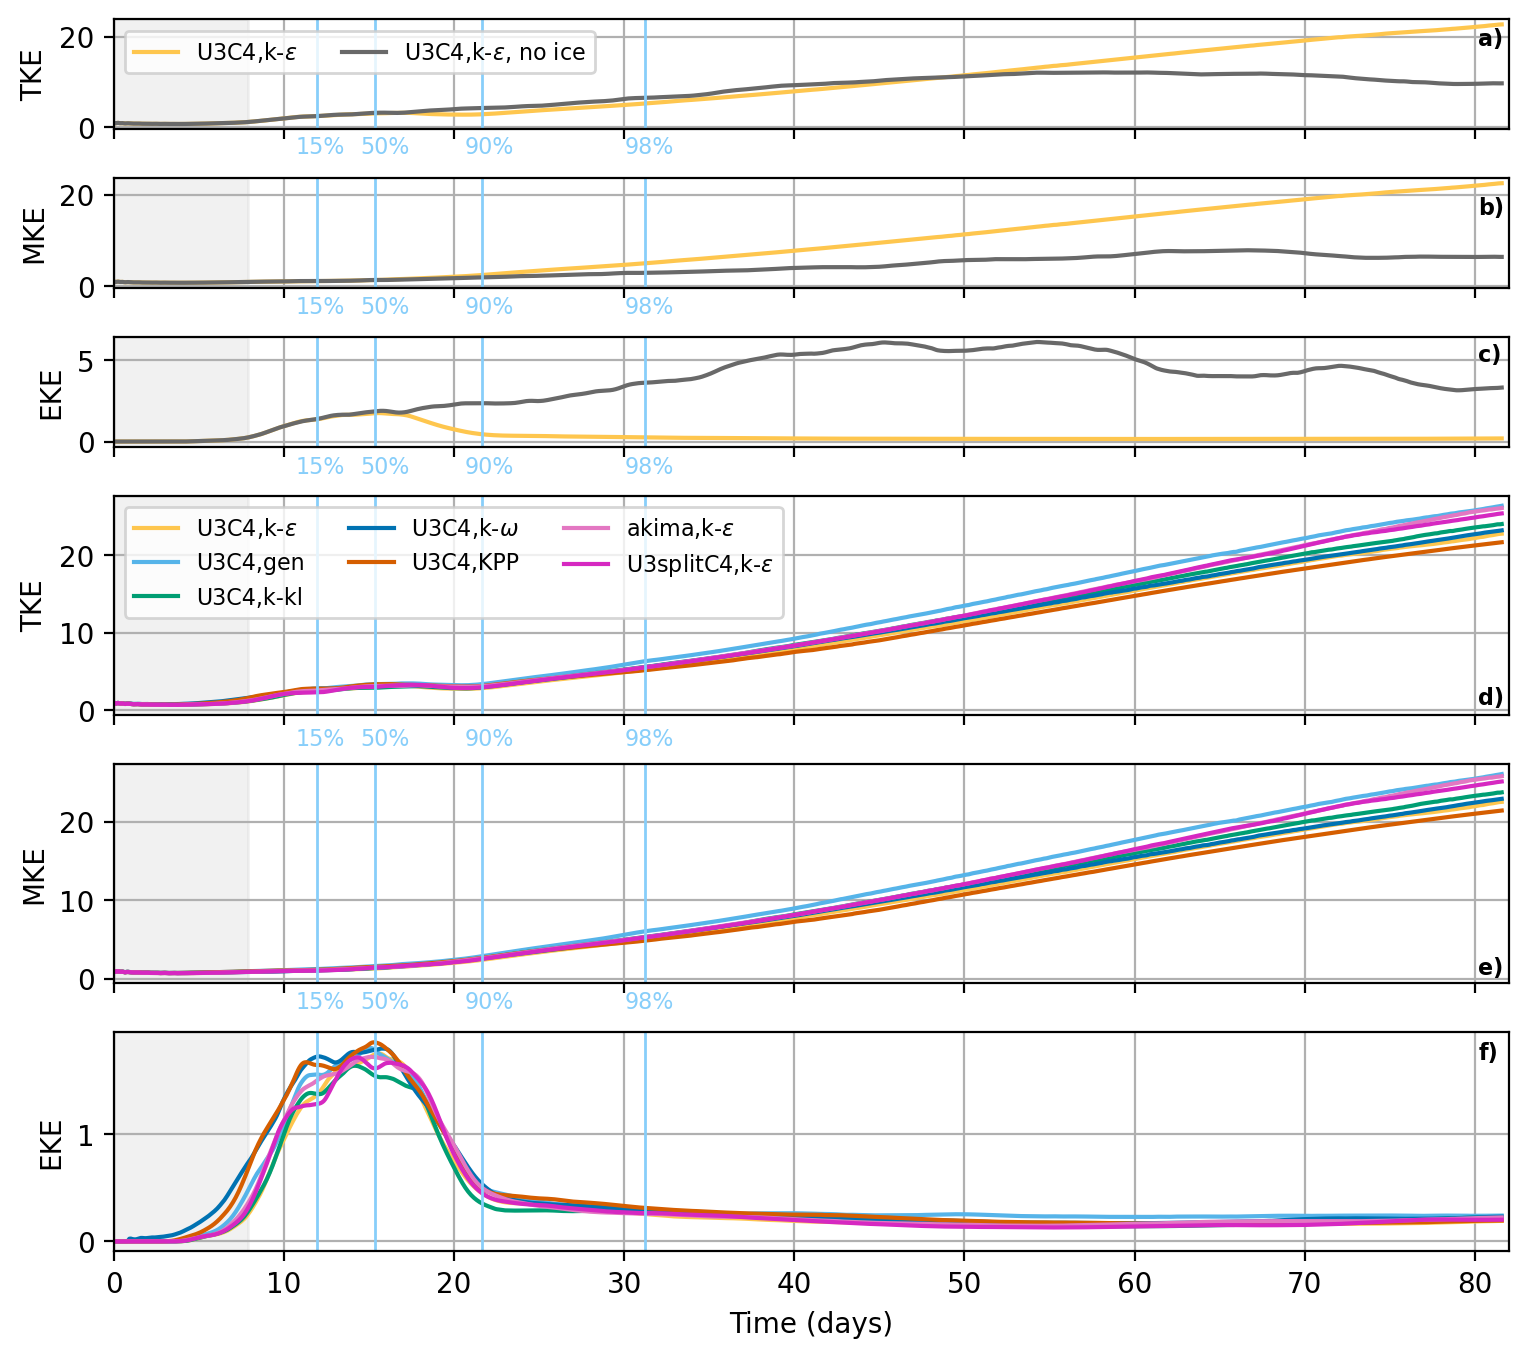

In [84]:
# Split off ice vs. no ice and add all the ice stat things 

# Make the figure 
fig, ax = plt.subplots(6, 1, figsize=(9,8), gridspec_kw={'height_ratios': [0.5, 0.5, 0.5, 1, 1, 1]},
                        dpi=200)

# --- Ice vs. No Ice ---
# Plot TKE
# --- Vertical Mixing Schemes ---
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[0].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.tke[:980] / roms_energetics_u3c4_keps.mke[0]), label = 'U3C4,k-$\epsilon$', color=energy_colors_all[0])
# Run without sea ice, 500 m resolution, u3c4, k-epsilon
ax[0].plot(roms_energetics_u3c4_keps_no_ice.ocean_time[:980], (roms_energetics_u3c4_keps_no_ice.tke[:980] / roms_energetics_u3c4_keps_no_ice.mke[0]), label = 'U3C4,k-$\epsilon$, no ice', color=energy_colors_all[1])
# Plot MKE
# --- Vertical Mixing Schemes ---
# plt.plot(time, dse.mke / dse.mke[0], label = 'MKE', color='powderblue')
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[1].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.mke[:980] / roms_energetics_u3c4_keps.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[0])
# Run without sea ice, 500 m resolution, u3c4, k-epsilon
ax[1].plot(roms_energetics_u3c4_keps_no_ice.ocean_time[:980], (roms_energetics_u3c4_keps_no_ice.mke[:980] / roms_energetics_u3c4_keps_no_ice.mke[0]), label = '$U3C4,k-\epsilon$, no ice', color=energy_colors_all[1])
# Plot EKE
# --- Vertical Mixing Schemes ---
# plt.plot(time, dse.eke / dse.eke[0], label = 'EKE', color='lightblue')
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[2].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.eke[:980] / roms_energetics_u3c4_keps.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[0])
# Run without sea ice, 500 m resolution, u3c4, k-epsilon
ax[2].plot(roms_energetics_u3c4_keps_no_ice.ocean_time[:980], (roms_energetics_u3c4_keps_no_ice.eke[:980] / roms_energetics_u3c4_keps_no_ice.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[1])




# --- Different Ice Runs ---
# Plot TKE
# --- Vertical Mixing Schemes ---
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[3].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.tke[:980] / roms_energetics_u3c4_keps.mke[0]), label = 'U3C4,k-$\epsilon$', color=energy_colors_all[0])
# Constant forcing, U3C4, gen
ax[3].plot(roms_energetics_u3c4_gen.ocean_time[:980], (roms_energetics_u3c4_gen.tke[:980] / roms_energetics_u3c4_gen.mke[0]), label = 'U3C4,gen', color=energy_colors_all[2])
# Constant forcing, U3C4, kkl
ax[3].plot(roms_energetics_u3c4_kkl.ocean_time[:980], (roms_energetics_u3c4_kkl.tke[:980] / roms_energetics_u3c4_kkl.mke[0]), label = 'U3C4,k-kl', color=energy_colors_all[3])
# Constant forcing, U3C4, k-omega
ax[3].plot(roms_energetics_u3c4_komega.ocean_time[:980], (roms_energetics_u3c4_komega.tke[:980] / roms_energetics_u3c4_komega.mke[0]), label = 'U3C4,k-$\omega$', color=energy_colors_all[4])
# Constant forcing, U3C4, kpp
ax[3].plot(roms_energetics_u3c4_kpp.ocean_time[:980], (roms_energetics_u3c4_kpp.tke[:980] / roms_energetics_u3c4_kpp.mke[0]), label = 'U3C4,KPP', color=energy_colors_all[5])
# --- Horizontal Advection Schemes ---
# Constant forcing, akima, keps
ax[3].plot(roms_energetics_akima_keps.ocean_time[:980], (roms_energetics_akima_keps.tke[:980] / roms_energetics_akima_keps.mke[0]), label = 'akima,k-$\epsilon$', color=energy_colors_all[6])
# Constant forcing, HSIMT, keps
#ax[3].plot(roms_energetics_hsimt_keps.ocean_time[:980], (roms_energetics_hsimt_keps.tke[:980] / roms_energetics_hsimt_keps.mke[0]), label = '$HSIMT,k-\epsilon$', color=energy_colors_all[7])
# Constant forcing, MPDATA, keps
#ax[3].plot(roms_energetics_mpdata_keps.ocean_time[:980], (roms_energetics_mpdata_keps.tke[:980] / roms_energetics_mpdata_keps.mke[0]), label = '$MPDATA,k-\epsilon$', color=energy_colors_all[8])
# Constant forcing, U3splitC4, keps
ax[3].plot(roms_energetics_u3splitc4_keps.ocean_time[:980], (roms_energetics_u3splitc4_keps.tke[:980] / roms_energetics_u3splitc4_keps.mke[0]), label = 'U3splitC4,k-$\epsilon$', color=energy_colors_all[9])


# Plot MKE
# --- Vertical Mixing Schemes ---
# plt.plot(time, dse.mke / dse.mke[0], label = 'MKE', color='powderblue')
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[4].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.mke[:980] / roms_energetics_u3c4_keps.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[0])
# Constant forcing, U3C4, gen
ax[4].plot(roms_energetics_u3c4_gen.ocean_time[:980], (roms_energetics_u3c4_gen.mke[:980] / roms_energetics_u3c4_gen.mke[0]), label = '$U3C4,gen$', color=energy_colors_all[2])
# Constant forcing, U3C4, kkl
ax[4].plot(roms_energetics_u3c4_kkl.ocean_time[:980], (roms_energetics_u3c4_kkl.mke[:980] / roms_energetics_u3c4_kkl.mke[0]), label = '$U3C4,kkl$', color=energy_colors_all[3])
# Constant forcing, U3C4, k-omega
ax[4].plot(roms_energetics_u3c4_komega.ocean_time[:980], (roms_energetics_u3c4_komega.mke[:980] / roms_energetics_u3c4_komega.mke[0]), label = '$U3C4,k-\omega$', color=energy_colors_all[4])
# Constant forcing, U3C4, kpp
ax[4].plot(roms_energetics_u3c4_kpp.ocean_time[:980], (roms_energetics_u3c4_kpp.mke[:980] / roms_energetics_u3c4_kpp.mke[0]), label = '$U3C4,kpp$', color=energy_colors_all[5])
# --- Horizontal Advection Schemes ---
# Constant forcing, akima, keps
ax[4].plot(roms_energetics_akima_keps.ocean_time[:980], (roms_energetics_akima_keps.mke[:980] / roms_energetics_akima_keps.mke[0]), label = '$akima,k-\epsilon$', color=energy_colors_all[6])
# Constant forcing, HSIMT, keps
#ax[4].plot(roms_energetics_hsimt_keps.ocean_time[:980], (roms_energetics_hsimt_keps.mke[:980] / roms_energetics_hsimt_keps.mke[0]), label = '$HSIMT,k-\epsilon$', color=energy_colors_all[7])
# Constant forcing, MPDATA, keps
#ax[4].plot(roms_energetics_mpdata_keps.ocean_time[:980], (roms_energetics_mpdata_keps.mke[:980] / roms_energetics_mpdata_keps.mke[0]), label = '$MPDATA,k-\epsilon$', color=energy_colors_all[8])
# Constant forcing, U3splitC4, keps
ax[4].plot(roms_energetics_u3splitc4_keps.ocean_time[:980], (roms_energetics_u3splitc4_keps.mke[:980] / roms_energetics_u3splitc4_keps.mke[0]), label = '$U3splitC4,k-\epsilon$', color=energy_colors_all[9])

# Plot EKE
# --- Vertical Mixing Schemes ---
# plt.plot(time, dse.eke / dse.eke[0], label = 'EKE', color='lightblue')
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
ax[5].plot(roms_energetics_u3c4_keps.ocean_time[:980], (roms_energetics_u3c4_keps.eke[:980] / roms_energetics_u3c4_keps.mke[0]), label = '$U3C4,k-\epsilon$', color=energy_colors_all[0])
# Constant forcing, U3C4, gen
ax[5].plot(roms_energetics_u3c4_gen.ocean_time[:980], (roms_energetics_u3c4_gen.eke[:980] / roms_energetics_u3c4_gen.mke[0]), label = '$U3C4,gen$', color=energy_colors_all[2])
# Constant forcing, U3C4, kkl
ax[5].plot(roms_energetics_u3c4_kkl.ocean_time[:980], (roms_energetics_u3c4_kkl.eke[:980] / roms_energetics_u3c4_kkl.mke[0]), label = '$U3C4,kkl$', color=energy_colors_all[3])
# Constant forcing, U3C4, k-omega
ax[5].plot(roms_energetics_u3c4_komega.ocean_time[:980], (roms_energetics_u3c4_komega.eke[:980] / roms_energetics_u3c4_komega.mke[0]), label = '$U3C4,k-\omega$', color=energy_colors_all[4])
# Constant forcing, U3C4, kpp
ax[5].plot(roms_energetics_u3c4_kpp.ocean_time[:980], (roms_energetics_u3c4_kpp.eke[:980] / roms_energetics_u3c4_kpp.mke[0]), label = '$U3C4,kpp$', color=energy_colors_all[5])
# --- Horizontal Advection Schemes ---
# Constant forcing, akima, keps
ax[5].plot(roms_energetics_akima_keps.ocean_time[:980], (roms_energetics_akima_keps.eke[:980] / roms_energetics_akima_keps.mke[0]), label = '$akima,k-\epsilon$', color=energy_colors_all[6])
# Constant forcing, HSIMT, keps
#ax[5].plot(roms_energetics_hsimt_keps.ocean_time[:980], (roms_energetics_hsimt_keps.eke[:980] / roms_energetics_hsimt_keps.mke[0]), label = '$HSIMT,k-\epsilon$', color=energy_colors_all[7])
# Constant forcing, MPDATA, keps
#ax[5].plot(roms_energetics_mpdata_keps.ocean_time[:980], (roms_energetics_mpdata_keps.eke[:980] / roms_energetics_mpdata_keps.mke[0]), label = '$MPDATA,k-\epsilon$', color=energy_colors_all[8])
# Constant forcing, U3splitC4, keps
ax[5].plot(roms_energetics_u3splitc4_keps.ocean_time[:980], (roms_energetics_u3splitc4_keps.eke[:980] / roms_energetics_u3splitc4_keps.mke[0]), label = '$U3splitC4,k-\epsilon$', color=energy_colors_all[9])


# Add some things to all plots
for r in range(6):
    # Add gridlines
    ax[r].grid()

    # Set x-lim
    ax[r].set_xlim(0,82)

    # Put a vertical line for the different average ice conc across runs
    #ax[r].axvline(time_u3c4_keps[idx_10_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(roms_energetics_u3c4_keps.ocean_time[idx_15_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_25_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_35_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_45_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(roms_energetics_u3c4_keps.ocean_time[idx_50_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_60_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_70_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_80_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(roms_energetics_u3c4_keps.ocean_time[idx_90_perc], color='lightskyblue', linewidth=1.0)
    #ax[r].axvline(time_u3c4_keps[idx_95_perc], color='lightskyblue', linewidth=1.0)
    ax[r].axvline(roms_energetics_u3c4_keps.ocean_time[idx_98_perc], color='lightskyblue', linewidth=1.0)
    # colors I like: plum, lightpink, lightskyblue, 
    ax[r].set_xlim(0,82)
    # Shade the period where sea ice is forming near the coast and approaching the box
    # near land and about to reach the box
    ax[r].axvspan(0, roms_energetics_u3c4_keps.ocean_time[time_idx_15_perc_south_bnd], color='lightgray', alpha=0.3)

# Add legend
ax[0].legend(ncols=2, fontsize=8)
ax[3].legend(ncols=3, fontsize=8)
#ax[1].legend(ncols=3)
#ax[2].legend(ncols=3)

# Label Plots
# # x-axes
ax[0].set_xticklabels([])
ax[1].set_xticklabels([])
ax[2].set_xticklabels([])
ax[3].set_xticklabels([])
ax[4].set_xticklabels([])
ax[5].set_xlabel('Time (days)')


# y-axes
ax[0].set_ylabel('TKE')
ax[1].set_ylabel('MKE')
ax[2].set_ylabel('EKE')
ax[3].set_ylabel('TKE')
ax[4].set_ylabel('MKE')
ax[5].set_ylabel('EKE')

# titles
#fig.suptitle('Volume-integrated energetics, $z>-200$ m')
# ax[0].set_title('Total Kinetic Energy (TKE)', fontsize=10)
# ax[1].set_title('Mean Kinetic Energy (MKE)', fontsize=10)
# ax[2].set_title('Eddy Kinetic Energy (EKE)', fontsize=10)
# ax[3].set_title('Total Kinetic Energy (TKE)', fontsize=10)
# ax[4].set_title('Mean Kinetic Energy (MKE)', fontsize=10)
# ax[5].set_title('Eddy Kinetic Energy (EKE)', fontsize=10)

# Manually label the lines with their percentages
# ax[0]
fig.text(0.226, 0.796, '15%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.262, 0.796, '50%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.320, 0.796, '90%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.409, 0.796, '98%', color='lightskyblue', rotation=0, fontsize=8)
# ax[1]
fig.text(0.226, 0.696, '15%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.262, 0.696, '50%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.320, 0.696, '90%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.409, 0.696, '98%', color='lightskyblue', rotation=0, fontsize=8)
# ax[2]
fig.text(0.226, 0.596, '15%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.262, 0.596, '50%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.320, 0.596, '90%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.409, 0.596, '98%', color='lightskyblue', rotation=0, fontsize=8)
# ax[3]
fig.text(0.226, 0.426, '15%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.262, 0.426, '50%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.320, 0.426, '90%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.409, 0.426, '98%', color='lightskyblue', rotation=0, fontsize=8)
# ax[4]
fig.text(0.226, 0.262, '15%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.262, 0.262, '50%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.320, 0.262, '90%', color='lightskyblue', rotation=0, fontsize=8)
fig.text(0.409, 0.262, '98%', color='lightskyblue', rotation=0, fontsize=8)

fig.subplots_adjust(hspace=0.30)

# Add subplot labels
fig.text(0.883, 0.864, 'a)', color='black', weight='bold', fontsize=8)
fig.text(0.883, 0.758, 'b)', color='black', weight='bold', fontsize=8)
fig.text(0.883, 0.666, 'c)', color='black', weight='bold', fontsize=8)
fig.text(0.883, 0.452, 'd)', color='black', weight='bold', fontsize=8)
fig.text(0.883, 0.283, 'e)', color='black', weight='bold', fontsize=8)
fig.text(0.883, 0.230, 'f)', color='black', weight='bold', fontsize=8)


In [ ]:
# Plot time series comparing horizontal advection schemes 

In [13]:
roms_energetics_u3c4_gen

<xarray.Dataset> Size: 35kB
Dimensions:     (ocean_time: 1104)
Coordinates:
  * ocean_time  (ocean_time) float64 9kB 0.0 0.08333 0.1667 ... 91.83 91.92
Data variables:
    tke         (ocean_time) float64 9kB ...
    mke         (ocean_time) float64 9kB ...
    eke         (ocean_time) float64 9kB ...
Attributes:
    description:  Time-series of energetics of ROMS output including EKE, MKE...

In [ ]:
# Plot energetics
fig, ax = plt.subplots(1,1, figsize=(9,2.75),dpi=150)

# Normalize by initial MKE so the total energy is one
plt.plot(time, dse.tke / dse.tke[0], label = 'TKE', color='navyblue')
plt.plot(time, dse.mke / dse.mke[0], label = 'MKE', color='powderblue')
plt.plot(time, dse.eke / dse.mke[0], label = 'EKE', color='lightblue')

plt.grid()
plt.legend()
plt.xlabel('Time [d]')
plt.title('Volume-integrated energetics, $z>-200$ m')

## Process the Output - $M^{2}$ & $N^{2}$

**Guiding Math**  

So we want to loop through each cell and calculate:   

**Density**  
$$
\rho = \rho_0 [1 + 7.6*10^{-4} (salt-S_0) - 1.7*10^{-4} (temp - T_0)]
$$

where   
$\rho_0 = 1025.0$  $kg/m^{3}$  
$S_0 = 34.0$ $PSU$  
$T_0 = 2.0 \degree C$  

**Bouyancy**  
$$
b = \frac{g(\rho_0 - \rho)}{\rho_0}
$$

where  
$g = 9.81$ $m/s^{2}$

**Gradients/Derivatives in Buoyancy**   
Horizontal will be used for $M^{2}$ and vertical will be used for $N^{2}$

$$
M^{2} = \sqrt{(\frac{\partial b}{\partial x})^{2} + (\frac{\partial b}{\partial y})^{2}}
$$
$$
N^{2} = \frac{\partial b}{\partial z}
$$  

And the distances can be calculated by  
$$
dx = R \cos(\phi)\Delta \lambda  
$$
$$
dy = R \Delta \phi  
$$
where  
$\phi$ = latitude  
$\Delta \lambda$ is the difference in degrees longitude  
for $dy$ the $\Delta \phi$ is in radians 

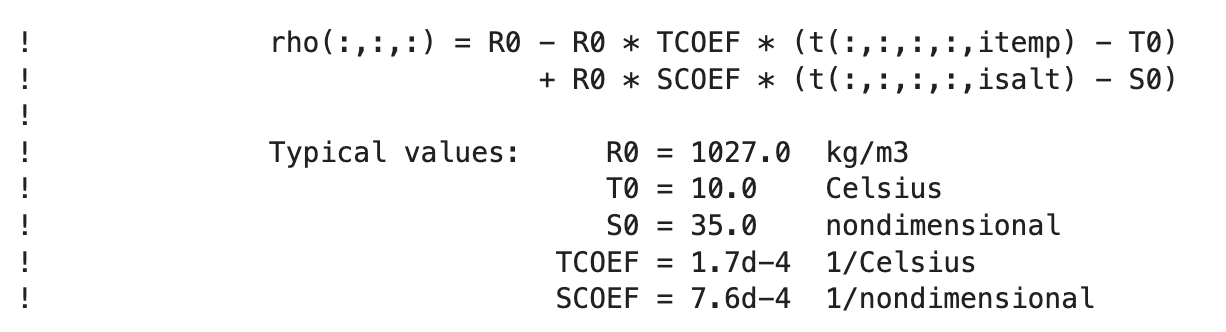

In [9]:
# Set the constants for the math
# Density
R0    = 1027.0     # kg/m^3
# Temperature 
T0    = 0.5       # Celsius
# Salinity 
S0    = 31       # nondimensional
# Coefficient for temperature for... (nonlinear equation of state?)
TCOEF = 1.7e-4     # 1/Celsius
# Coefficient for salinity for... (nonlinear equation of state?)
SCOEF = 7.6e-4     # 1/nondimensional

In [10]:
# Calculate density 
rho = R0*(1 - (TCOEF * (ds.temp - T0)) + (SCOEF * (ds.salt - S0)))

rho.name = 'rho'

In [11]:
# Calculate N2 and put it on the rho grid
N2 = xroms.N2(rho, grid, rho0=1025.0)

# Interpolate to rho points
N2_rho = grid.interp(N2, 'Z', boundary = 'extend')


In [12]:
print(np.shape(N2))
print(N2[0,10,100,100].values)
#print(np.where(np.isnan(N2)))

(1440, 41, 1002, 402)
3.2648125155476494e-05


In [13]:
N2_rho[100,10,:,:].min().values

array(-2.69723837e-05)

In [14]:
np.log10(-3.45032853e-05)

nan

In [15]:
# The cells below to get N2 PDF are crashing either because
# of negative values in the log (so do signed version like Gemini
# suggested) and/or because the vertical slicing is somehow returning 
# nans everywhere...
# I think the vertical slicing...except no it still happens when I
# take that part out

In [20]:
len(n2_bins)

60

In [16]:
# Set the bins and normalize
# Compute PDF, normalize by max value so the max is one
n2_bins = np.arange(-5.5,-2.5,0.05)

n2_pdf = histogram(np.log10(abs(N2_rho.isel(eta_rho=eta_slice, xi_rho=xi_slice).where(ds.z_rho>-200))), #.where(ds.z_rho>-200), 
                   bins = n2_bins, 
                   block_size=N2_rho.ocean_time.size,
                   dim = ['s_rho','xi_rho', 'eta_rho'],
                   density=True).compute()

#n2_bins_log = np.logspace(-5.5, -2.5, 60)
# n2_pdf = histogram(N2_rho.where(ds.z_rho>-z_slice), 
#                    bins = n2_bins_log, 
#                    dim = ['s_rho','xi_rho', 'eta_rho'],
#                    density=True).compute()

n2_pdf = n2_pdf / n2_pdf.max()

KeyboardInterrupt: 

In [ ]:
# Gemini help to do signed log since we have 
# unstable stratification in some areas
# Adjust range based on absolute value version then run this later

# # Create a signed log variable
# # We add a tiny offset or use .where to avoid log(0)
# N2_signed_log = np.sign(N2_rho) * np.log10(np.abs(N2_rho).where(N2_rho > 1e-12))

# # Adjust your bins to cover the negative range too
# # e.g., from -8 to -5 (negative side) and 5 to 8 (positive side)
# n2_bins = np.concatenate([np.arange(-8, -4.95, 0.05), 
#                           np.arange(5, 8.05, 0.05)]) 

# n2_pdf = histogram(N2_signed_log.where(ds.z_rho>-z_slice), 
#                    bins = n2_bins, 
#                    dim = ['s_rho','xi_rho', 'eta_rho'],
#                    density=True).compute()

# n2_pdf = n2_pdf / n2_pdf.max()


In [ ]:
# Make a vector for time
# Time vector
time = n2_pdf['ocean_time']
t0 = time.values[0]

time_num = np.array([
    (t - t0).total_seconds() / 86400
    for t in time.values
])

In [ ]:
# Calculate M2
# Set the gravitational constant 
g = 9.807

# Calculate buoyancy
b = -g * ( (rho-R0) / R0)

# Calculate horizontal gradients accounting for s-coordinate
# NOT needed if looking at surface only, then a simple grid.diff will do!
dbdx, dbdy = xroms.hgrad(b.where(ds.z_rho>-z_slice),grid)
dbdx = xroms.to_rho(dbdx,grid)
dbdx = grid.interp(dbdx,'Z')
dbdy = xroms.to_rho(dbdy,grid)
dbdy = grid.interp(dbdy,'Z')

# Calculate M2 from these gradients 
M2 = np.sqrt(dbdx**2+dbdy**2)

In [ ]:
print(np.max(M2))

In [ ]:
# Compute PDF, normalize by max value so the max is one
m2_bins = np.arange(-8,-5.,0.05)
m2_pdf = histogram(np.log10(M2), 
                   bins = m2_bins, 
                   block_size=M2.ocean_time.size,
                   dim = ['xi_rho', 'eta_rho','s_rho'],
                   density=True).compute()
m2_pdf = m2_pdf / m2_pdf.max()

### Save to a NetCDF  
Save the post-processed data to a netcdf so it can be read in for plotting.

In [ ]:
# Save the data to a netcdf

# Variables to save: N2, n2_bins, n2_pdf, M2, m2_bins, m2_pdf

roms_M2_N2 = xr.Dataset(
    data_vars=dict(
        N2=(['ocean_time'], N2),
        n2_bins=(['n2_bin_len'], n2_bins),
        n2_pdf=(['ocean_time'], n2_pdf),
        M2=(['ocean_time'], M2),
        m2_bins=(['m2_bin_len'], m2_bins),
        m2_pdf=(['ocean_time'], m2_pdf),
    ),
    coords=dict(
        ocean_time=('ocean_time', ds.ocean_time.values),
        n2_bin_len=('n2_bin_len', len(n2_bins)),
        m2_bin_len=('m2_bin_len', len(m2_bins)),
    ),
    attrs=dict(description='Time-series of parameters of ROMS output including N2, M2, and their normalized PDFs and bins from 2-hourly model output; uses /global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps*.nc')
)

# Add attributes to the 'temperature' data variable
roms_M2_N2['N2'].attrs['long_name'] = 'N2, vertical stratification'
roms_M2_N2['N2'].attrs['units'] = '($s^{-2}$)'
roms_M2_N2['n2_pdf'].attrs['long_name'] = 'normalized PDF of N2'
roms_M2_N2['n2_pdf'].attrs['units'] = '(fraction)'
roms_M2_N2['n2_bins'].attrs['long_name'] = 'bins used for N2 PDF'
roms_M2_N2['n2_bins'].attrs['units'] = '($s^{-2}$)'

roms_M2_N2['M2'].attrs['long_name'] = 'M2, magnitude of lateral buoyancy gradients'
roms_M2_N2['M2'].attrs['units'] = '($s^{-2}$)'
roms_M2_N2['m2_pdf'].attrs['long_name'] = 'normalized PDF of M2'
roms_M2_N2['m2_pdf'].attrs['units'] = '(fraction)'
roms_M2_N2['m2_bins'].attrs['long_name'] = 'bins used for M2 PDF'
roms_M2_N2['m2_bins'].attrs['units'] = '($s^{-2}$)'

# Save to a netcdf
# Run with ice
#roms_M2_N2.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_M2_N2_2hr_ice_500m_const_forc_u3c4_keps_001.nc')
# Run without ice
#roms_M2_N2.to_netcdf('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_M2_N2_2hr_no_ice_500m_const_forc_u3c4_keps_001.nc')


### Plot the Output - $M^{2}$ & $N^{2}$

In [38]:
# Load in the post-processed output to plot below 
# once the post-processing is done
# Load in post-processed data
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
#roms_M2_N2_u3c4_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_M2_N2_2hr_500m_const_forc_u3c4_keps_001.nc')

# Run without sea ice, 500 m resolution, u3c4, k-epsilon
#roms_M2_N2_u3c4_keps_no_ice = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_M2_N2_2hr_500m_const_forc_no_ice_u3c4_keps_001.nc')

# Constant forcing, U3C4, gen
roms_M2_N2_u3c4_gen = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/roms_N2_M2_2hr_500m_const_forc_u3c4_gen_001.nc')

# Constant forcing, U3C4, kkl
#roms_M2_N2_u3c4_kkl = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_N2_M2_2hr_500m_const_forc_u3c4_kkl_001.nc')

# Constant forcing, U3C4, k-omega
#roms_M2_N2_u3c4_komega = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_N2_M2_2hr_500m_const_forc_u3c4_komega_001.nc')

# Constant forcing, U3C4, kpp
#roms_M2_N2_u3c4_kpp = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_N2_M2_2hr_500m_const_forc_u3c4_kpp_001.nc')

# Constant forcing, akima, k-epsilon
#roms_M2_N2_akima_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_M2_N2_2hr_500m_const_forc_akima_keps_001.nc')

# Constant forcing, HSIMT, k-epsilon
#roms_M2_N2_hsimt_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_M2_N2_2hr_500m_const_forc_hsimt_keps_001.nc')

# Constant forcing, MPDATA, k-epsilon
#roms_M2_N2_mpdata_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_M2_N2_2hr_500m_const_forc_mpdata_keps_001.nc')

# Constant forcing, u3splitc4, k-epsilon
#roms_M2_N2_u3splitc4_keps = xr.open_dataset('/global/cfs/cdirs/m4572/bundzis/roms_idealized_beaufort_jet/Post_process_data/roms_M2_N2_2hr_500m_const_forc_u3splitc4_keps_001.nc')


In [39]:
# Make a time for each output
# Run with sea ice, 500 m resolution, u3c4, k-epsilon
# time_tmp = roms_M2_N2_u3c4_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Run without sea ice, 500 m resolution, u3c4, k-epsilon
# time_tmp = roms_M2_N2_u3c4_keps_no_ice['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_keps_no_ice = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, gen
# time_tmp = roms_M2_N2_u3c4_gen['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_gen = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, kkl
# time_tmp = roms_M2_N2_u3c4_kkl['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_kkl = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, k-omega
# time_tmp = roms_M2_N2_u3c4_komega['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_komega = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, U3C4, kpp
# time_tmp = roms_M2_N2_u3c4_kpp['ocean_time']
# t0 = time_tmp.values[0]
# time_u3c4_kpp = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, akima, k-epsilon
# time_tmp = roms_M2_N2_akima_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_akima_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, HSIMT, k-epsilon
# time_tmp = roms_M2_N2_hsimt_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_hsimt_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, MPDATA, k-epsilon
# time_tmp = roms_M2_N2_mpdata_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_mpdata_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Constant forcing, u3splitc4, k-epsilon
# time_tmp = roms_M2_N2_u3splitc4_keps['ocean_time']
# t0 = time_tmp.values[0]
# time_u3splitc4_keps = np.array([(t - t0).total_seconds() / 86400 for t in time_tmp.values])

# Make time array to use for plotting 
# # Time vector
# # I think do some stuff to get a vector of time for plotting?
# time = ds['ocean_time']
# t0 = time.values[0]

# time = np.array([
#     (t - t0).total_seconds() / 86400
#     for t in time.values
# ])

In [40]:
roms_M2_N2_u3c4_gen

<xarray.Dataset> Size: 285GB
Dimensions:     (ocean_time: 1104, s_rho: 40, eta_rho: 1002, xi_rho: 402,
                 n2_bins: 59, m2_bins: 59)
Coordinates:
  * ocean_time  (ocean_time) float64 9kB 0.0 0.08333 0.1667 ... 91.83 91.92
  * n2_bins     (n2_bins) float64 472B -5.5 -5.45 -5.4 -5.35 ... -2.7 -2.65 -2.6
  * m2_bins     (m2_bins) float64 472B -8.0 -7.95 -7.9 -7.85 ... -5.2 -5.15 -5.1
  * s_rho       (s_rho) float64 320B -0.9875 -0.9625 -0.9375 ... -0.0375 -0.0125
  * eta_rho     (eta_rho) int64 8kB 0 1 2 3 4 5 6 ... 996 997 998 999 1000 1001
  * xi_rho      (xi_rho) int64 3kB 0 1 2 3 4 5 6 ... 395 396 397 398 399 400 401
Data variables:
    N2          (ocean_time, s_rho, eta_rho, xi_rho) float64 142GB ...
    n2_pdf      (ocean_time, n2_bins) float64 521kB ...
    M2          (ocean_time, s_rho, eta_rho, xi_rho) float64 142GB ...
    m2_pdf      (ocean_time, m2_bins) float64 521kB ...
Attributes:
    description:  Time-series of parameters of ROMS output including N2, M2, ...

In [41]:
# Reassign variables 


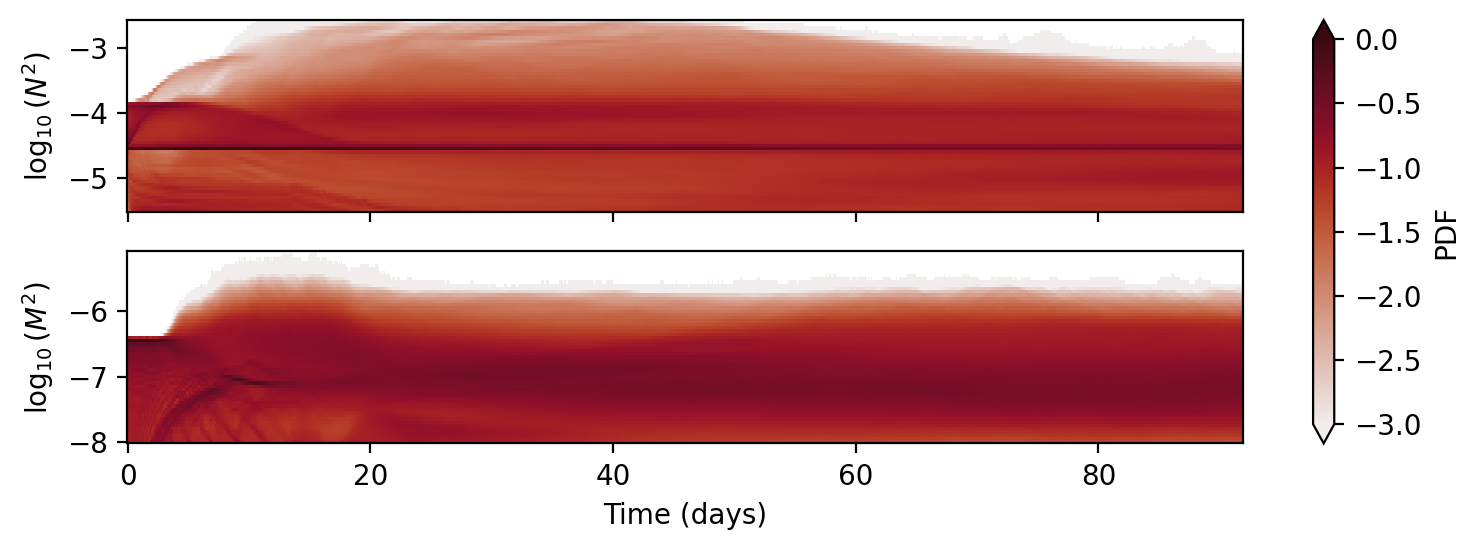

In [47]:
# Plot N2
fig, ax = plt.subplots(2, figsize=(9, 2.75), dpi=200)

# Plot N2
p1 = ax[0].pcolormesh(
    roms_M2_N2_u3c4_gen.ocean_time,
    roms_M2_N2_u3c4_gen.n2_bins,
    np.log10(roms_M2_N2_u3c4_gen.n2_pdf.T.where(roms_M2_N2_u3c4_gen.n2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)
# Make a colorbar
# cbar1 = fig.colorbar(p1, ax=ax[0], extend='both')
# cbar1.set_label('PDF')

# Plot M2
p2 = ax[1].pcolormesh(
    roms_M2_N2_u3c4_gen.ocean_time,
    roms_M2_N2_u3c4_gen.m2_bins,
    np.log10(roms_M2_N2_u3c4_gen.m2_pdf.T.where(roms_M2_N2_u3c4_gen.m2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)
# Make a colorbar
cbar2 = fig.colorbar(p2, ax=[ax[0],ax[1]], extend='both')
cbar2.set_label('PDF')

ax[0].set_xticklabels('')
ax[1].set_xlabel('Time (days)')
ax[0].set_ylabel(r'$\log_{10}(N^2)$')
ax[1].set_ylabel(r'$\log_{10}(M^2)$')

plt.show()

In [ ]:
# Plot N2
fig, ax = plt.subplots(figsize=(9, 2.75), dpi=200)

pcm = ax.pcolormesh(
    time_num,
    n2_pdf.N2_bin,
    np.log10(n2_pdf.T.where(n2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)

ax.set_xlabel('Time [d]')
ax.set_ylabel(r'$\log_{10}(N^2)$')

cbar = fig.colorbar(pcm, ax=ax, extend='both')
cbar.set_label('PDF')

plt.show()

AttributeError: 'Dataset' object has no attribute 'm2_bins'

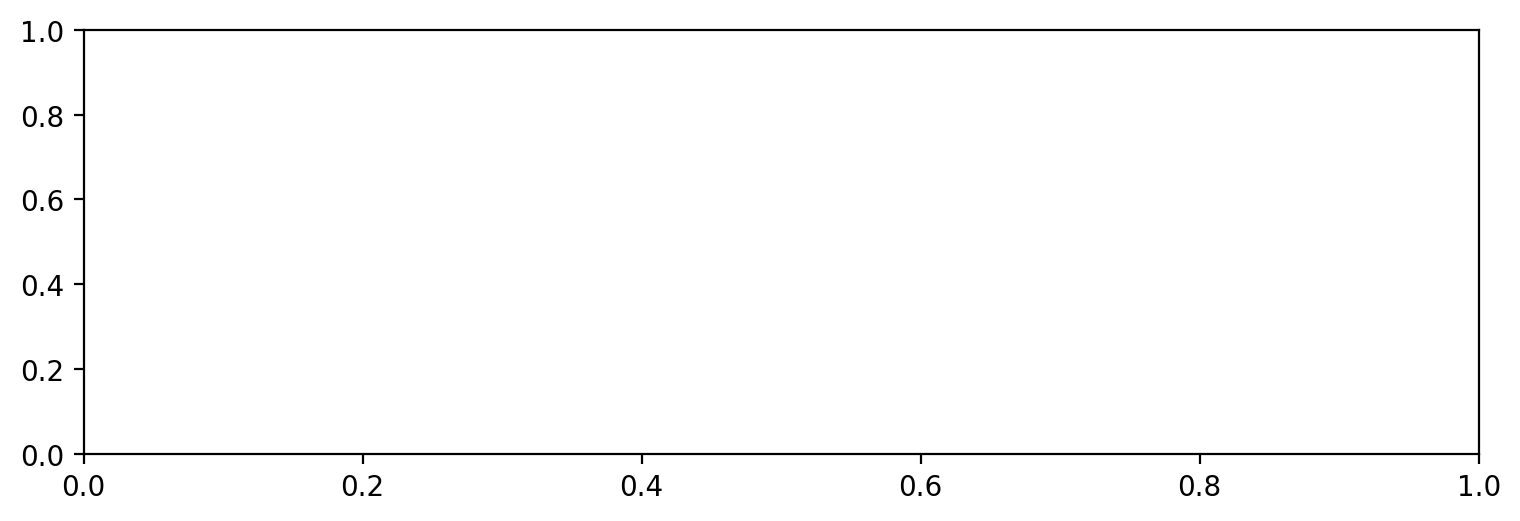

In [25]:
fig, ax = plt.subplots(figsize=(9, 2.75), dpi=200)

pcm = ax.pcolormesh(
    roms_M2_N2_u3c4_gen.ocean_time,
    roms_M2_N2_u3c4_gen.m2_bins,
    np.log10(roms_M2_N2_u3c4_gen.m2_pdf.T.where(roms_M2_N2_u3c4_gen.m2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)

ax.set_xlabel('Time [days]')
ax.set_ylabel(r'$\log_{10}(N^2)$')

cbar = fig.colorbar(pcm, ax=ax, extend='both')
cbar.set_label('PDF')

In [ ]:
# Plot M2
fig, ax = plt.subplots(figsize=(9, 3), dpi=200)

pcm = ax.pcolormesh(
    time_num,
    m2_pdf.drhodxi_bin,
    np.log10(m2_pdf.T.where(m2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)

ax.set_xlabel('Time [d]')
ax.set_ylabel(r'$\log_{10}(M^2)$')

cbar = fig.colorbar(pcm, ax=ax, extend='both')
cbar.set_label('PDF')

plt.show()

### Plot the Output - Energetics & $M^{2}$ & $N^{2}$

In [ ]:
# Make a plot with M2, N2, and energetics 

# Make the figure 
fig, axs = plt.subplots(
    3, 1,
    figsize=(9, 6),
    dpi=200,
    sharex=True,
    constrained_layout=True
)

# ======================
# 1) Energetics (top)
# ======================
ax = axs[0]

ax.plot(time_num, dse.tke / dse.tke[0], label='TKE')
ax.plot(time_num, dse.mke / dse.mke[0], label='MKE')
ax.plot(time_num, dse.eke / dse.mke[0], label='EKE')

ax.set_ylabel('Normalized energy')
ax.set_title('Volume-integrated energetics, $z > -200$ m')
ax.grid()
ax.legend(loc='best')


# ======================
# 2) N² PDF (middle)
# ======================
ax = axs[1]

pcm_n2 = ax.pcolormesh(
    time_num,
    n2_pdf.N2_bin,
    np.log10(n2_pdf.T.where(n2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)

def ten_power_formatter(x, pos):
    return rf'$10^{{{x:.1f}}}$'

ax.set_ylabel(r'[s$^{-2}$]')
ax.yaxis.set_major_formatter(FuncFormatter(ten_power_formatter))
ax.grid()
ax.set_title('$N^2$, $z>-150$ m')

cbar_n2 = fig.colorbar(
    pcm_n2, ax=ax, extend='both', pad=0.02, format=ticker.FormatStrFormatter('$10^{%.1f}$')
)
cbar_n2.set_label('PDF')


# ======================
# 3) M² PDF (bottom)
# ======================
ax = axs[2]

pcm_m2 = ax.pcolormesh(
    time_num,
    m2_pdf.drhodxi_bin,
    np.log10(m2_pdf.T.where(m2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0, 
)

ax.set_xlabel('Time [d]')
ax.set_ylabel(r'[s$^{-2}$]')
ax.yaxis.set_major_formatter(FuncFormatter(ten_power_formatter))
ax.set_title('$M^2$, $z>-150$ m')
ax.grid()

cbar_m2 = fig.colorbar(
    pcm_m2, ax=ax, extend='both', pad=0.02, format=ticker.FormatStrFormatter('$10^{%.1f}$')
)
cbar_m2.set_label('PDF')

plt.show()
